                            QUESTION 3 : PREDICTING HOTEL PRICES IN FEB 2022

                                LIBRARIES: PANDAS, MATPLOTLIB, DATETIME

                                MODEL: PROPHET
                                
                                DATASETS: FEB2015.CSV, FEBCOMPLETE.CSV

Since we are forecasting ~7 years beyond the last data point, a single model may not capture all real-world factors. Two complementary approaches are used:

1. Heurestic (Formula Based)
2. Prophet (ML Based)

                                        HEURISTIC APPROACH

In [2]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from datetime import date


A transparent simple approach that manually incorporates three known factors:

- Annual growth (10%) — Derived from the average February price growth observed across 2012–2015

- Inflation (23.5%) — Cumulative US inflation from 2015 to 2022, sourced from usinflationcalculator.com

- COVID dampening (0.5) — Accounts for the pandemic's severe impact on travel demand in 2020–2021, which suppressed hotel prices 

The predicted Feb 2022 prices will based from the latest year prices available i.e. Feb 2015

In [3]:
# Fetching 2015 Feb data 

feb_df = pd.read_csv('Feb2015.csv')
feb_df.head()

,DATE,PRICE
0,2015-02-01,133
1,2015-02-02,143
2,2015-02-03,141
3,2015-02-04,160
4,2015-02-05,148


## CALCULATING THE ANNUAL GROWTH

In [4]:
def calculate_predicted_price(feb_df):

    #--------------------  ANNUAL GROWTH 
    '''
    Calculated the average growth for the month of feb from the year 2012 - 2015 using SQL (View = Feb_growth)
    Average growth of the hotel prices per year was around 10%
    '''
    avg_growth = 0.1
    target_year = 2022

    #years_gap = target_year - latest_year = 2022-2015 = 7
    years_gap = 7
    total_organic_increase = (1 + avg_growth)**years_gap


    #------------ INFLATION FACTOR
    '''
     Source: https://www.usinflationcalculator.com/ 
     Average Inflation rise from 2015 to 2022: 23.5%
     
    '''
    
    infaltion_rate= 0.235
    final_inflation = 1 + infaltion_rate
    
    #----------------- COVID SHOCK FACTOR 
    '''
     Adjusts for the pandemic travel and labor shortages after its severe hit during 2021
     I have assumed the dampening covid factor as 40% 
     
    '''
    shock_factor = 0.6
    

    #-------------------- INCORPORATING ALL THESE VALUES 
    feb_df['2022_predicted'] = 0.0
    
    for i in range(len(feb_df)):
    
        # PREDICTED PRICE = 2015_PRICE * annual_increase * inflation * covid_factor
            feb_df['2022_predicted'] = (feb_df['PRICE'] * total_organic_increase * final_inflation * shock_factor).round(2)
    return feb_df


In [7]:
updated_df = calculate_predicted_price(feb_df)
updated_df.head()

,DATE,PRICE,2022_predicted
0,2015-02-01,133,192.05
1,2015-02-02,143,206.49
2,2015-02-03,141,203.60
3,2015-02-04,160,231.04
4,2015-02-05,148,213.71


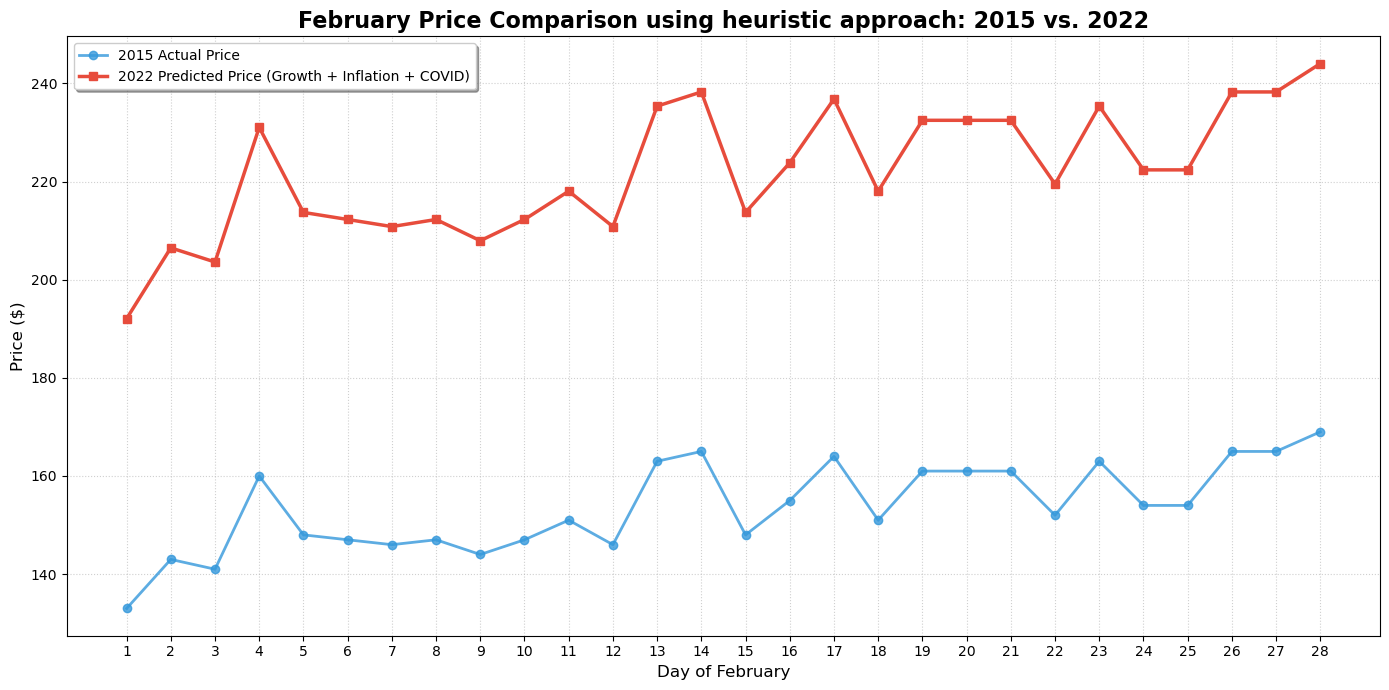

In [9]:
#PLOT 1
plt.figure(figsize=(14, 7))

days = range(1, len(updated_df) + 1)

plt.plot(days, updated_df['PRICE'], 
         label='2015 Actual Price', 
         color='#3498db', marker='o',linewidth = 2, alpha=0.8)

plt.plot(days, updated_df['2022_predicted'], 
         label='2022 Predicted Price (Growth + Inflation + COVID)', 
         color='#e74c3c', marker='s', linewidth=2.5)


plt.title('February Price Comparison using heuristic approach: 2015 vs. 2022', fontsize=16, fontweight='bold')
plt.xlabel('Day of February', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.xticks(days) # Shows every day 1-28
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, shadow=True)


plt.tight_layout()
plt.show()

## RESULTS AND CONCLUSIONS:

- Average price for the year 2022 fluctuates around $190 - $240

- This is a guesstimate approach since Annual growth rate and COVID impact has been assumed, but still gives us a vague idea of an estimated price range



                                                MACHINE LEARNING APPROACH



# WHY PROPHET MODEL 

- Unlike general ML models, Prophet is built for time-series forecasting

- It can automatically model trend and seasonality, which are key drivers in hotel pricing

- It is also more interpretable and requires less data (4 Years of dataset) and feature engineering compared to complex ML approaches
 

In [10]:
# Complete data for all the years ( 2012 - 2015 )

trained_data_df = pd.read_csv('raw.csv')

df_prophet = trained_data_df[['DATE', 'PRICE']].copy()
df_prophet.columns = ['ds', 'y']   #standard prophet columns

df_prophet.head()

,ds,y
0,2012-01-01,99
1,2012-01-02,95
2,2012-01-03,96
3,2012-01-04,95
4,2012-01-05,93


In [11]:
###    TRAINING THE MODEL

# add yearly and weekly seasonality
# daily requires time so it's set to false
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,   
)

# adding a holdidays factor : Rise on 14th Feb
# Upper/Lower window = Affect of the holidays, I will assume 2 days
holidays = pd.DataFrame({
    'holiday': 'peak_season',
    'ds': pd.to_datetime([
        '2012-02-14', '2013-02-14', '2014-02-14', '2015-02-14',
    ]),
    'lower_window': -2,
    'upper_window': 2,
})

model = Prophet(holidays=holidays)

# Added a monghtly seasonality with period loop of 30.5 days 
## fourier order to capture complex varitions if any (risk of overfitting)
model.add_seasonality(name='monthy', period=30.5, fourier_order=5)



In [12]:
###     FITTING AND PREDICTING

model.fit(df_prophet)

future = model.make_future_dataframe(periods=2500)  # till 2022
forecast = model.predict(future)

feb_2022 = forecast[
    (forecast['ds'].dt.year == 2022) & 
    (forecast['ds'].dt.month == 2)
][['ds', 'yhat']]

feb_2022.head()

14:24:37 - cmdstanpy - INFO - Chain [1] start processing
14:24:38 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat
3683,2022-02-01,192.317207
3684,2022-02-02,193.516160
3685,2022-02-03,193.938118
3686,2022-02-04,195.684145
3687,2022-02-05,195.016087


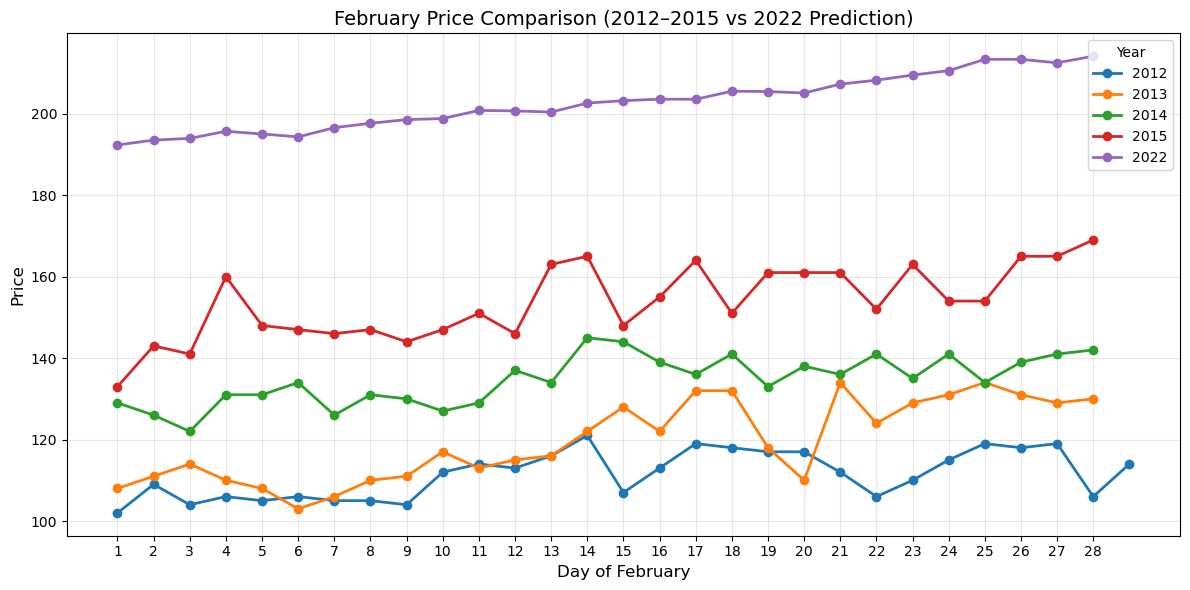

In [13]:
all_data = trained_data_df.copy()
all_data['DATE'] = pd.to_datetime(all_data['DATE'])

all_data = all_data[all_data['DATE'].dt.month == 2].copy()

all_data['day'] = all_data['DATE'].dt.day
all_data['YEAR'] = all_data['DATE'].dt.year

all_data = all_data.groupby(['YEAR', 'day'])['PRICE'].mean().reset_index()

feb_2022['ds'] = pd.to_datetime(feb_2022['ds'])
feb_2022_plot = feb_2022[
    (feb_2022['ds'] >= '2022-02-01') &
    (feb_2022['ds'] <= '2022-02-28')
].copy()

feb_2022_plot['day'] = feb_2022_plot['ds'].dt.day
feb_2022_plot['YEAR'] = 2022
feb_2022_plot.rename(columns={'yhat': 'PRICE'}, inplace=True)

combined = pd.concat([
    all_data[['day', 'PRICE', 'YEAR']],
    feb_2022_plot[['day', 'PRICE', 'YEAR']]
])

combined = combined.sort_values(by=['YEAR', 'day'])

plt.figure(figsize=(12,6))

for year, group in combined.groupby('YEAR'):
    plt.plot(group['day'], group['PRICE'], marker='o', linewidth=2, label=str(year))

plt.title("February Price Comparison (2012–2015 vs 2022 Prediction)", fontsize=14)
plt.xlabel("Day of February", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.xticks(range(1, 29))
plt.legend(title="Year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model Tuning:

- Incorporated a holiday component to capture event-driven demand spikes, specifically around February 14th

- Added a monthly seasonality component to model intra-month variations that are not captured by yearly or weekly patterns

## COMPARISON BETWEEN THE PREDICTED PRICES

In [14]:
# Heuristic model 
h_max = updated_df['2022_predicted'].max()
h_min = updated_df['2022_predicted'].min()
h_avg = updated_df['2022_predicted'].mean()

# Prophet model
p_max = feb_2022['yhat'].max()
p_min = feb_2022['yhat'].min()
p_avg = feb_2022['yhat'].mean()

print("MODEL PREDICTED RESULTS COMPARISON")
print("------------------------------------")
print("\nHEURISTIC MODEL STATISTICS:")
print(f"Maximum: ${h_max:,.2f}")
print(f"Minimum: ${h_min:,.2f}")
print(f"Average: ${h_avg:,.2f}")

print("\nPROPHET MODEL STATISTICS:")
print(f"Maximum: ${p_max:,.2f}")
print(f"Minimum: ${p_min:,.2f}")
print(f"Average: ${p_avg:,.2f}")

print(f"\n\nDifference in averages: ${abs(h_avg - p_avg):,.2f}")


MODEL PREDICTED RESULTS COMPARISON
------------------------------------

HEURISTIC MODEL STATISTICS:
Maximum: $244.04
Minimum: $192.05
Average: $221.96

PROPHET MODEL STATISTICS:
Maximum: $214.12
Minimum: $192.32
Average: $202.72


Difference in averages: $19.25


By comparing the two approaches, we can safely predict that prices of Feb 2022 to be in the range of $160- $200 

The Heuristic model serves as a vital reality check for large-scale economic shocks, while the Prophet model provides the necessary seasonal accuracy to understand daily price movements. 

Together, they suggest a 2022 price landscape that is substantially transformed but still follows the seasonal rhythms established in previous years.

                                        END OF ASSIGNMENT THANK YOU :)